In [169]:
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
from os.path import isfile
from astropy.table import Table
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

### Skip the following if you dont want to query the database yourself

In [170]:
Gaia.login() # You might want to create your own account if you want to query the data yourself

INFO: Login to gaia TAP server [astroquery.gaia.core]
401 Error 401:
<!doctype html><html lang="en"><head><title>HTTP Status 401 – Unauthorized</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} h1 {font-size:22px;} h2 {font-size:16px;} h3 {font-size:14px;} p {font-size:12px;} a {color:black;} .line {height:1px;background-color:#525D76;border:none;}</style></head><body><h1>HTTP Status 401 – Unauthorized</h1><hr class="line" /><p><b>Type</b> Status Report</p><p><b>Message</b> Bad Credentials</p><p><b>Description</b> The request has not been applied to the target resource because it lacks valid authentication credentials for that resource.</p><hr class="line" /><h3>Apache Tomcat/9.0.82</h3></body></html>


ERROR: Error logging in TAP server [astroquery.gaia.core]


#### Printing Information about available tables and table contents

In [171]:
def print_available_gaiadr3_tables():    
    tables = Gaia.load_tables(only_names=True)
    for table in tables:
        name: str = table.get_qualified_name()
        if name.startswith("gaiadr3"):
            print(name)
print_available_gaiadr3_tables()

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
gaiadr3.gaiadr3.gaia_source
gaiadr3.gaiadr3.gaia_source_lite
gaiadr3.gaiadr3.astrophysical_parameters
gaiadr3.gaiadr3.astrophysical_parameters_supp
gaiadr3.gaiadr3.oa_neuron_information
gaiadr3.gaiadr3.oa_neuron_xp_spectra
gaiadr3.gaiadr3.total_galactic_extinction_map
gaiadr3.gaiadr3.total_galactic_extinction_map_opt
gaiadr3.gaiadr3.commanded_scan_law
gaiadr3.gaiadr3.allwise_best_neighbour
gaiadr3.gaiadr3.allwise_neighbourhood
gaiadr3.gaiadr3.apassdr9_best_neighbour
gaiadr3.gaiadr3.apassdr9_join
gaiadr3.gaiadr3.apassdr9_neighbourhood
gaiadr3.gaiadr3.dr2_neighbourhood
gaiadr3.gaiadr3.gsc23_best_neighbour
gaiadr3.gaiadr3.gsc23_join
gaiadr3.gaiadr3.gsc23_neighbourhood
gaiadr3.gaiadr3.hipparcos2_best_neighbour
gaiadr3.gaiadr3.hipparcos2_neighbourhood
gaiadr3.gaiadr3.panstarrs1_best_neighbour
gaiadr3.gaiadr3.panstarrs1_join
gaiadr3.gaiadr3.pansta

In [172]:
def print_columns(table = "gaiadr3.gaia_source"):
  gaiadr3_table = Gaia.load_table(table)
  print(f"{'NAME':<35}{'UNIT':<20}{'DESCRIPTION':<200}")
  for column in gaiadr3_table.columns:
    print(f"{str(column.name):<35}{str(column.unit):<20}{str(column.description):<200}")
print_columns()

NAME                               UNIT                DESCRIPTION                                                                                                                                                                                             
solution_id                        None                Solution Identifier                                                                                                                                                                                     
designation                        None                Unique source designation (unique across all Data Releases)                                                                                                                                             
source_id                          None                Unique source identifier (unique within a particular Data Release)                                                                                                               

### Downloading Gaia Data

In [173]:
# TAP-query for downloading data
RERUN = False
filename = "C:/Users/Ruben/Desktop/All_candidates_200pc_noparallaxovererror.vot"
if (not isfile(filename)) or RERUN:
    query = """
    SELECT 
        l, 
        b, 
        ra,
        ra_error,
        dec,
        dec_error,
        parallax, 
        parallax_error,
        pmra, 
        pmra_error,
        pmdec, 
        pmdec_error,
        phot_g_mean_mag, 
        teff_gspphot,
        bp_rp,
        radial_velocity,
        radial_velocity_error
    FROM 
        gaiadr3.gaia_source AS gdr3
    WHERE 
        teff_gspphot BETWEEN 4000 AND 5000
        AND parallax > 0.5 -- within 2 kpc
        AND (1000.0/parallax * COS(b*PI()/180)) < 200 -- within a cylinder of 200 pc width
    """
    #AND parallax_over_error > 5 -- Ensures useful parallax measurement

    # Perform TAP query
    job = Gaia.launch_job_async(query)  # This runs for <30min
    results = job.get_results()

    # Print the first few rows
    # print(results)

    # Save to file
    results.write(filename, format="votable", overwrite=True)
    print("Data download complete.")
else:
    print("Data file found. Skipping Gaia query.")

Data file found. Skipping Gaia query.


### mit T und M sollten nur K-dwarfs übrig bleiben vgl. Hertzsprung-Russel

### End of Gaia query part

#### Loading Data-Table

In [174]:
# tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc.vot")
# print(len(tab)) #632951
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_noparallaxovererror.vot")
# print(len(tab)) #644675

#### What subsample can be expected to be volume-complete?

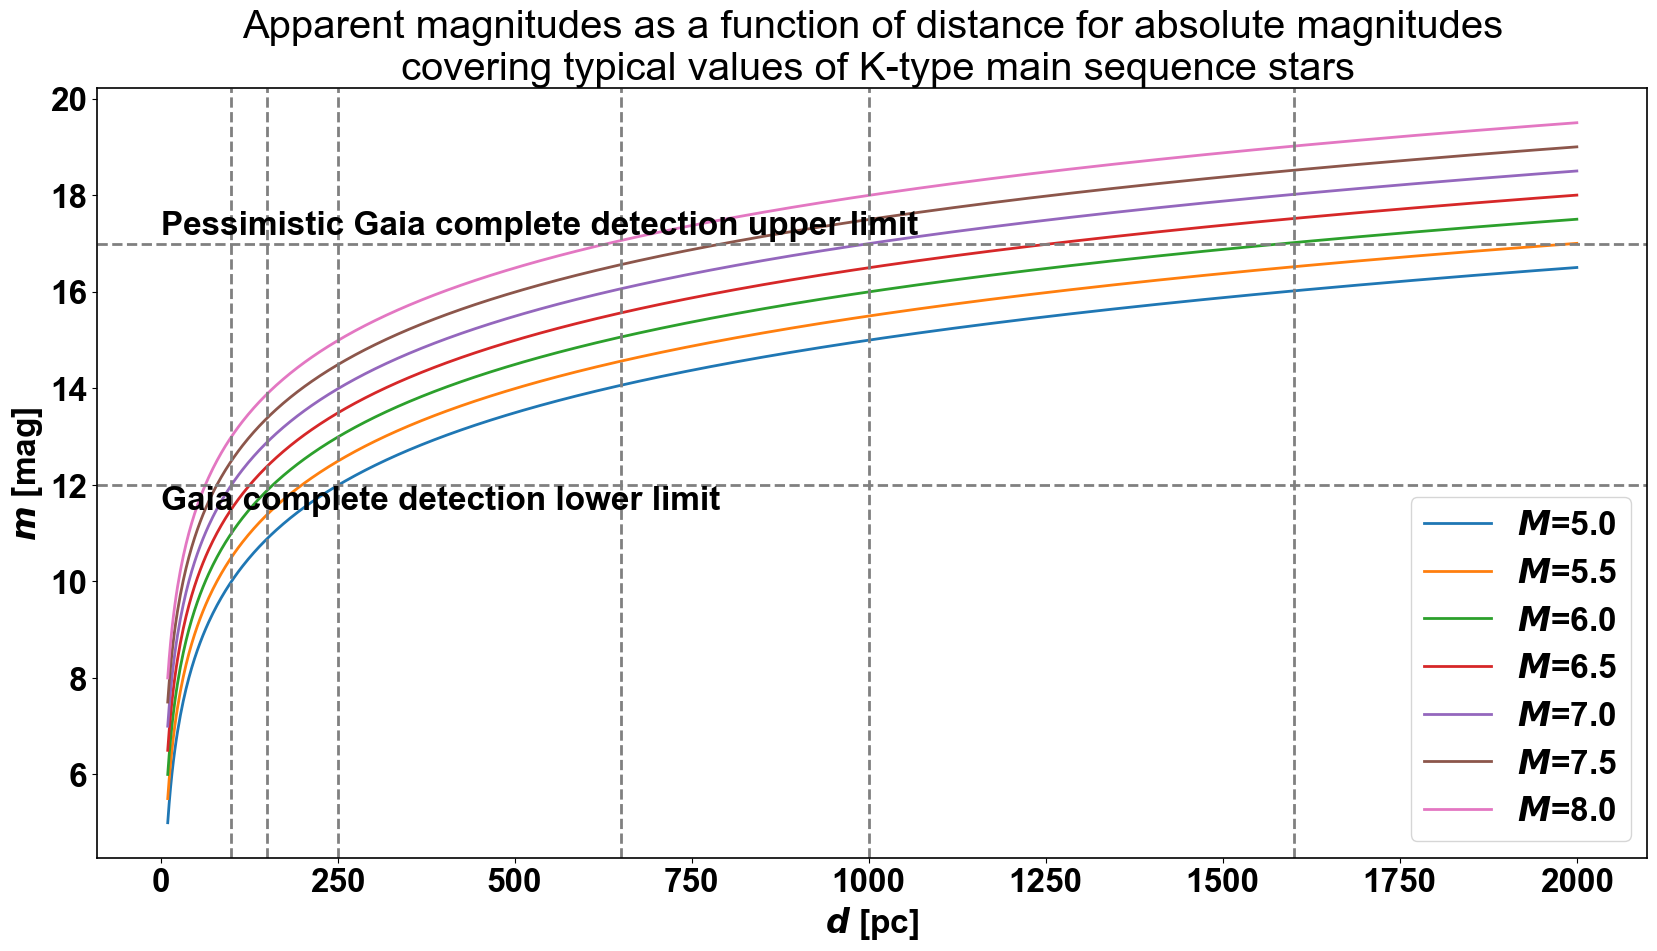

In [175]:
def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

plt.figure(figsize=(20,10))
Ms = np.linspace(5, 8, 7) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2}".format(M))

plt.axhline(17.0, color="gray", ls="--")
plt.axhline(12.0, color="gray", ls="--")
plt.axvline(650, color="gray", ls="--")
plt.axvline(1000, color="gray", ls="--")
plt.axvline(1600, color="gray", ls="--")
plt.axvline(100, color="gray", ls="--")
plt.axvline(150, color="gray", ls="--")
plt.axvline(250, color="gray", ls="--")

plt.text(0, 17.2, "Pessimistic Gaia complete detection upper limit")
plt.text(0, 11.5, "Gaia complete detection lower limit")

plt.ylabel(r"$m$ [mag]")
plt.xlabel(r"$d$ [pc]")
plt.title("Apparent magnitudes as a function of distance for absolute magnitudes\n covering typical values of K-type main sequence stars")
plt.legend()
plt.show()
# See also https://gea.esac.esa.int/archive/documentation/GDR3/Catalogue_consolidation/chap_cu9val/sec_cu9val_introduction/ssec_cu9val_intro_completeness.html
# and links therein
# Fig.14.38 suggests that most of the persumably missed stars originiate from a mismodelled disc and high latitudes are fine (-> perhaps we can go higher than 17 mag)
# Though, I would not trust this hope. Perhaps it would be best to split the dataset into two or three (e.g. like this):
    # M=5-6 and d<2000pc
    # M=6-8 and d<1000pc

    #safe intervals:    M=5-6, d=250-1600
    #                   M=6-7, d=150-1000
    #                   M=7-8, d=100-650


### z dependence of stars with inaccurate parallaxe measurment

Requirement: parallax/standarterror(parallax) is larger than 5. This ensures useful parallax measurment. Removes an additional 1.17e+04 sources
We are left with 6.33e+05 sources


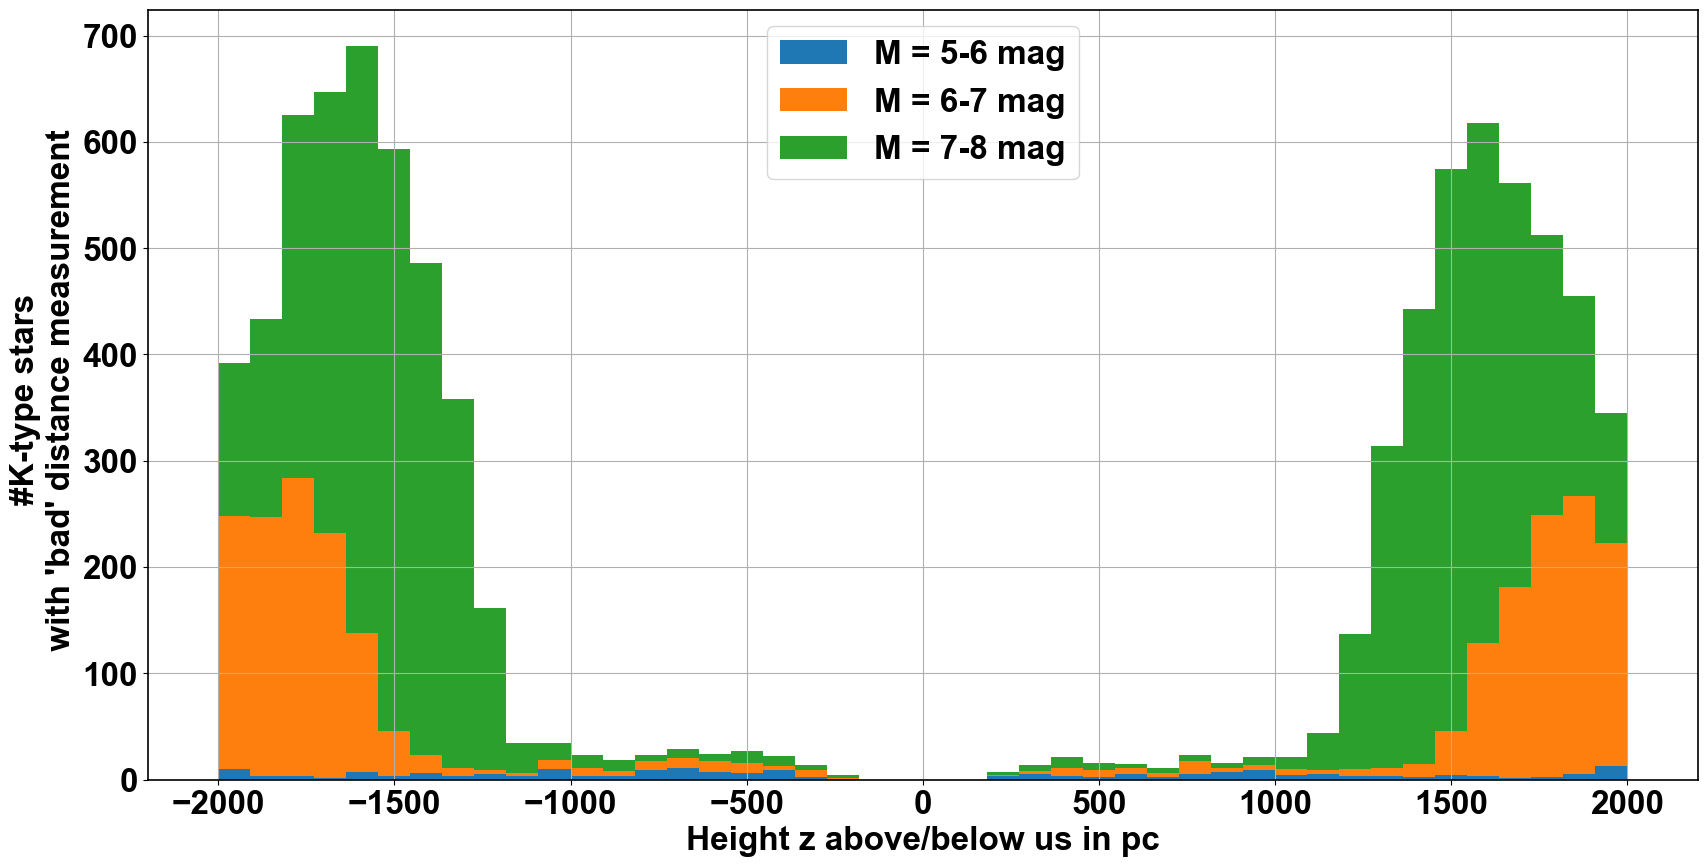

In [176]:
# Distance
deg2rad = np.pi/180.
dist_pc = 1000./tab["parallax"] # in pc
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
min = 5
mask0 = parallax_over_error > min
group1 = (absolute_magnitude[~mask0] >= 5) & (absolute_magnitude[~mask0] < 6)
group2 = (absolute_magnitude[~mask0] >= 6) & (absolute_magnitude[~mask0] < 7)
group3 = (absolute_magnitude[~mask0] >= 7) & (absolute_magnitude[~mask0] <= 8)
z_out = (dist_pc*np.sin(tab["b"]*deg2rad))[~mask0]
absolute_magnitude_out = absolute_magnitude[~mask0]

plt.figure(figsize=(20,10))
plt.hist([z_out[group1], z_out[group2], z_out[group3]], bins=44, stacked=True, range=(-2000, 2000), label=["M = 5-6 mag", "M = 6-7 mag", "M = 7-8 mag"])
plt.xlabel("Height z above/below us in pc")
plt.ylabel("#K-type stars \n with 'bad' distance measurement")
plt.grid()
plt.legend()

tab_pre = tab[mask0]
print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(min, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

#### Selecting a subsample

In [177]:
def filtration(am_min = 5.0, am_max = 8.0):
# make this smaller for better volume completeness (default 8.0)

    # # Cylinder with radius r_cyl #obsolete
    # r_cyl = 200. # pc # parallax > cos(lat)*5
    # mask = dist_pc * np.cos(tab["b"]*deg2rad) < r_cyl # 200 pc cylinder 
    # print("Requirement: Inside the cylinder of {} pc radius. Removes {:.2e} of {:.2e} sources".format(r_cyl, np.nansum(~mask), mask.size))
    # print("We are left with {:.2e} sources".format(np.nansum(mask)))

    # Cylinder symmetrical around galactic plane
    height = 1800. # pc
    mask1 = (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)<height-14.5) & (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)>-height-14.5)
    print("Requirement: Inside the cylinder of 2 * {} pc hight (centered at galactic plane!). Removes an additional {:.2e} sources".format(height, np.nansum(~mask1)))
    print("We are left with {:.2e} sources".format(np.nansum(mask1)))

    # Absolute magnitude limits
    mask2 = (absolute_magnitude[mask0]>=am_min) & (absolute_magnitude[mask0]<=am_max)
    print("Requirement: Absolute magnitude between {} and {}. Removes an additional {:.2e} sources".format(am_min, am_max, np.nansum(~mask2&mask1)))
    print("We are left with {:.2e} sources".format(np.nansum(mask1&mask2)))
    tab_filtered = tab[mask0][mask1&mask2]

    return tab_filtered

In [178]:
# Load into separate numpy arrays
def arrays(tab_filtered):
    np_arr = np.array(tab_filtered)

    l_np = np_arr["l"]
    b_np = np_arr["b"]
    ra_np = np_arr["ra"]
    ra_error_np = np_arr["ra_error"]
    dec_np = np_arr["dec"]
    dec_error_np = np_arr["dec_error"]
    parallax_np = np_arr["parallax"]
    parallax_error_np = np_arr["parallax_error"]
    pmra_np = np_arr["pmra"]
    pmra_error_np = np_arr["pmra_error"]
    pmdec_np = np_arr["pmdec"]
    pmdec_error_np = np_arr["pmdec_error"]
    phot_g_mean_mag_np = np_arr["phot_g_mean_mag"]
    teff_gspphot_np = np_arr["teff_gspphot"]
    bp_rp_np = np_arr["bp_rp"]
    radial_velocity_np = np_arr["radial_velocity"]
    radial_velocity_error_np = np_arr["radial_velocity_error"]

    del np_arr

    return l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np

# Vertical Distribution and Velocity Dispersion

In [179]:
###  Functions for computing the vertical velocity
def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    
    return v_z

# Velocity Dispersion

Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 5.0 and 8.0. Removes an additional 9.58e+04 sources
We are left with 5.36e+05 sources
Mean vertical velocity =  -7.975501361373122 km/s


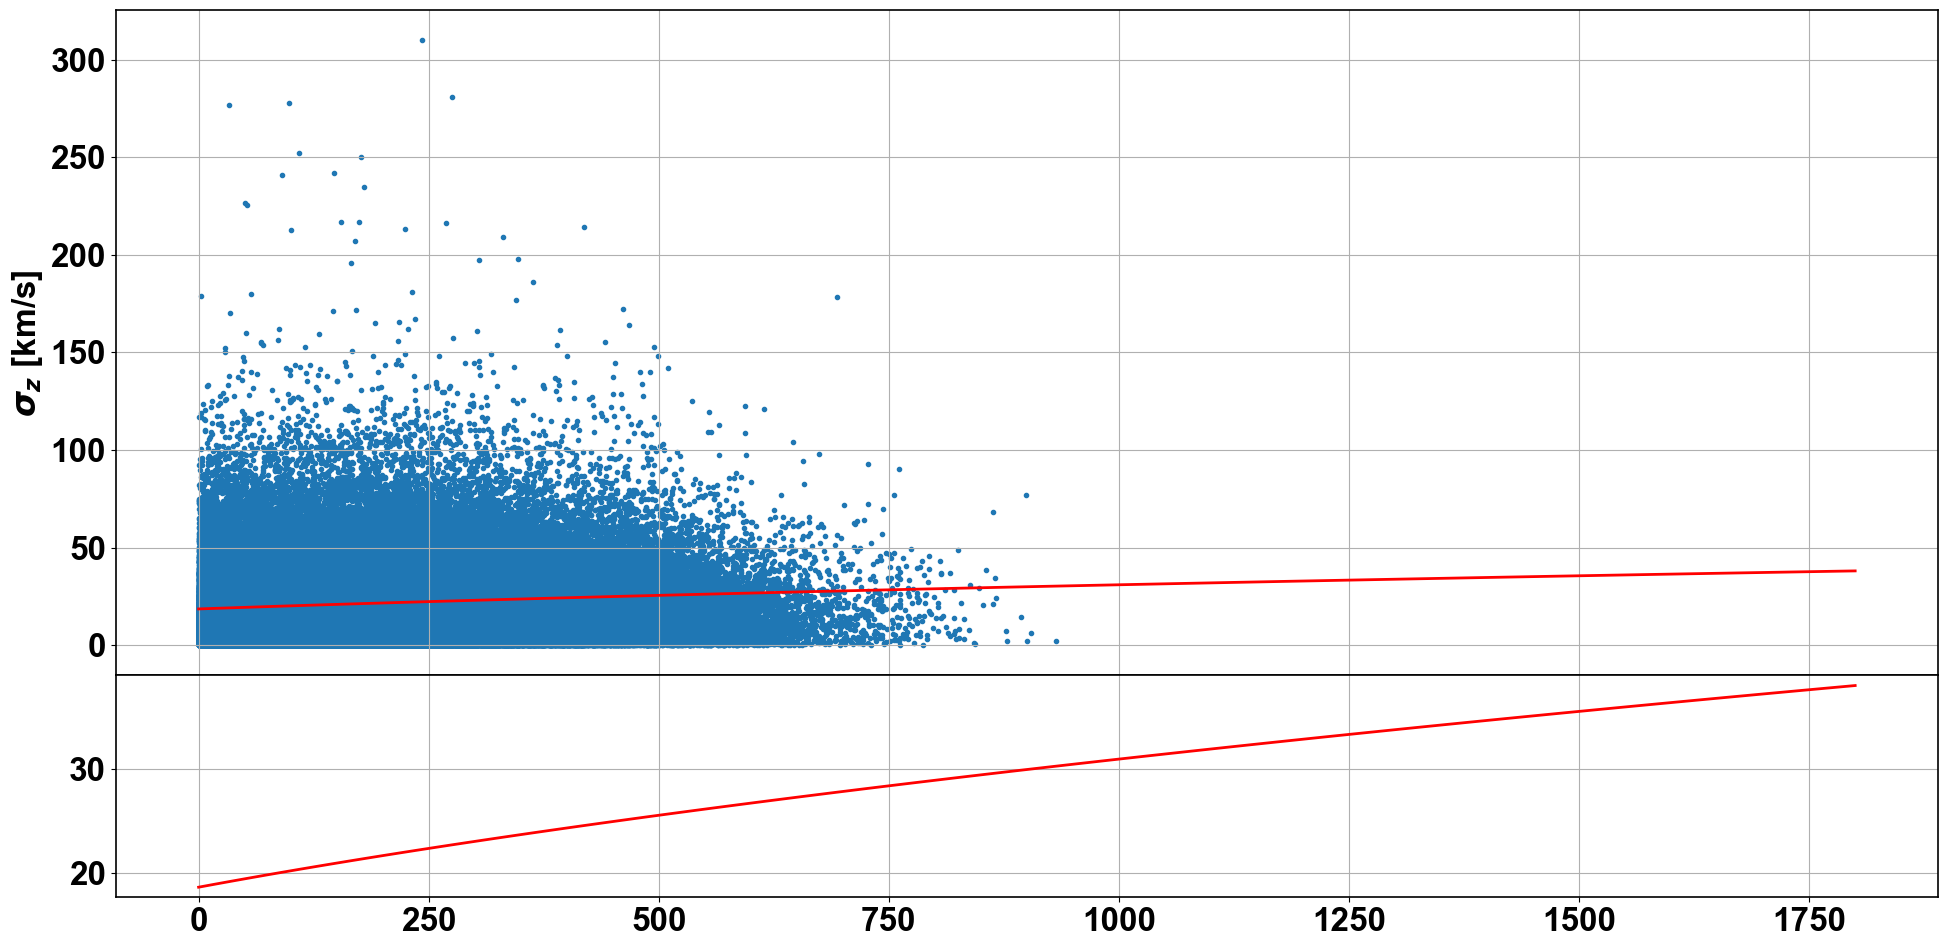

In [180]:
am_min = 5.0
am_max = 8.0
tab_filtered = filtration(am_min, am_max)
l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

r_np = r_from_plx(parallax_np)
z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

# Compute vertical velocity dispersion
vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
hasv = np.isfinite(vz) 
vmean = np.mean(vz[hasv])
print("Mean vertical velocity = ", vmean, "km/s")
v2 = (vz[hasv]-vmean)**2

# Lets fit a simple curve
POLYNOME_ORDER = 1
v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
zs = np.linspace(0, 1800, 100)
sigmas = np.sqrt(v2_fit(zs))
fig, ax = plt.subplots(2,1, figsize=(20,10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax[0].scatter(np.abs(z_np)[hasv], np.sqrt(v2), marker='.')
ax[0].plot(zs, sigmas, color='r')
ax[0].set_xlabel(r"$z$ [pc]")
ax[0].set_ylabel(r"$\sigma_z$ [km/s]")
ax[0].grid()
ax[1], plt.plot(zs, sigmas, color='r')
ax[1].grid()
plt.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

# Create a text file
np.savetxt(f'real data/poly_{am_min:.0f}{am_max:.0f}.txt', np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER), fmt='%f')

Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 6.81e+02 sources
We are left with 6.32e+05 sources
Requirement: Absolute magnitude between 5.0 and 6.0. Removes an additional 5.87e+05 sources
We are left with 4.52e+04 sources


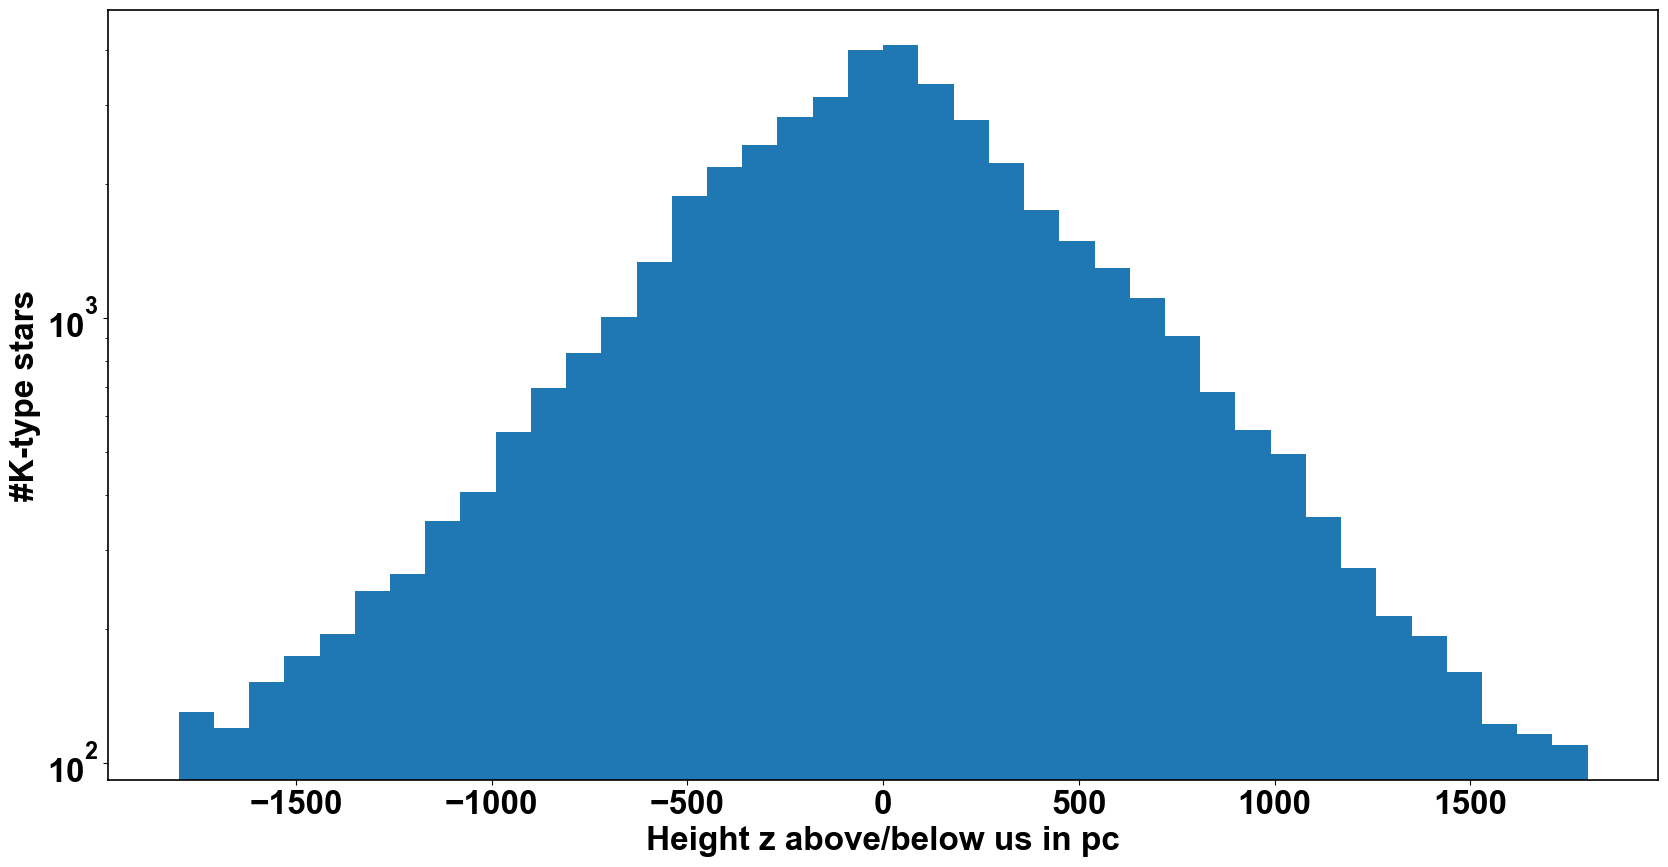

In [181]:
n_bins = 40

def Verarbeitung(am_min, am_max, n_bin):
    # Histogram in z
    tab_filtered = filtration(am_min, am_max)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    plt.figure(figsize=(20,10))
    n, bins, _ = plt.hist(z_np, bins=n_bin, range=(-1800, 1800))
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.show()

    # Create a text file
    np.savetxt(f'real data/n_{am_min:.0f}{am_max:.0f}.txt', n, fmt='%i')
    np.savetxt(f'real data/bins_{am_min:.0f}{am_max:.0f}.txt', bins, fmt='%f')

Verarbeitung(5.0, 6.0, n_bins)
# Verarbeitung(6.0, 7.0, n_bins)
# Verarbeitung(7.0, 8.0, n_bins)
# Verarbeitung(5.0, 8.0, n_bins)


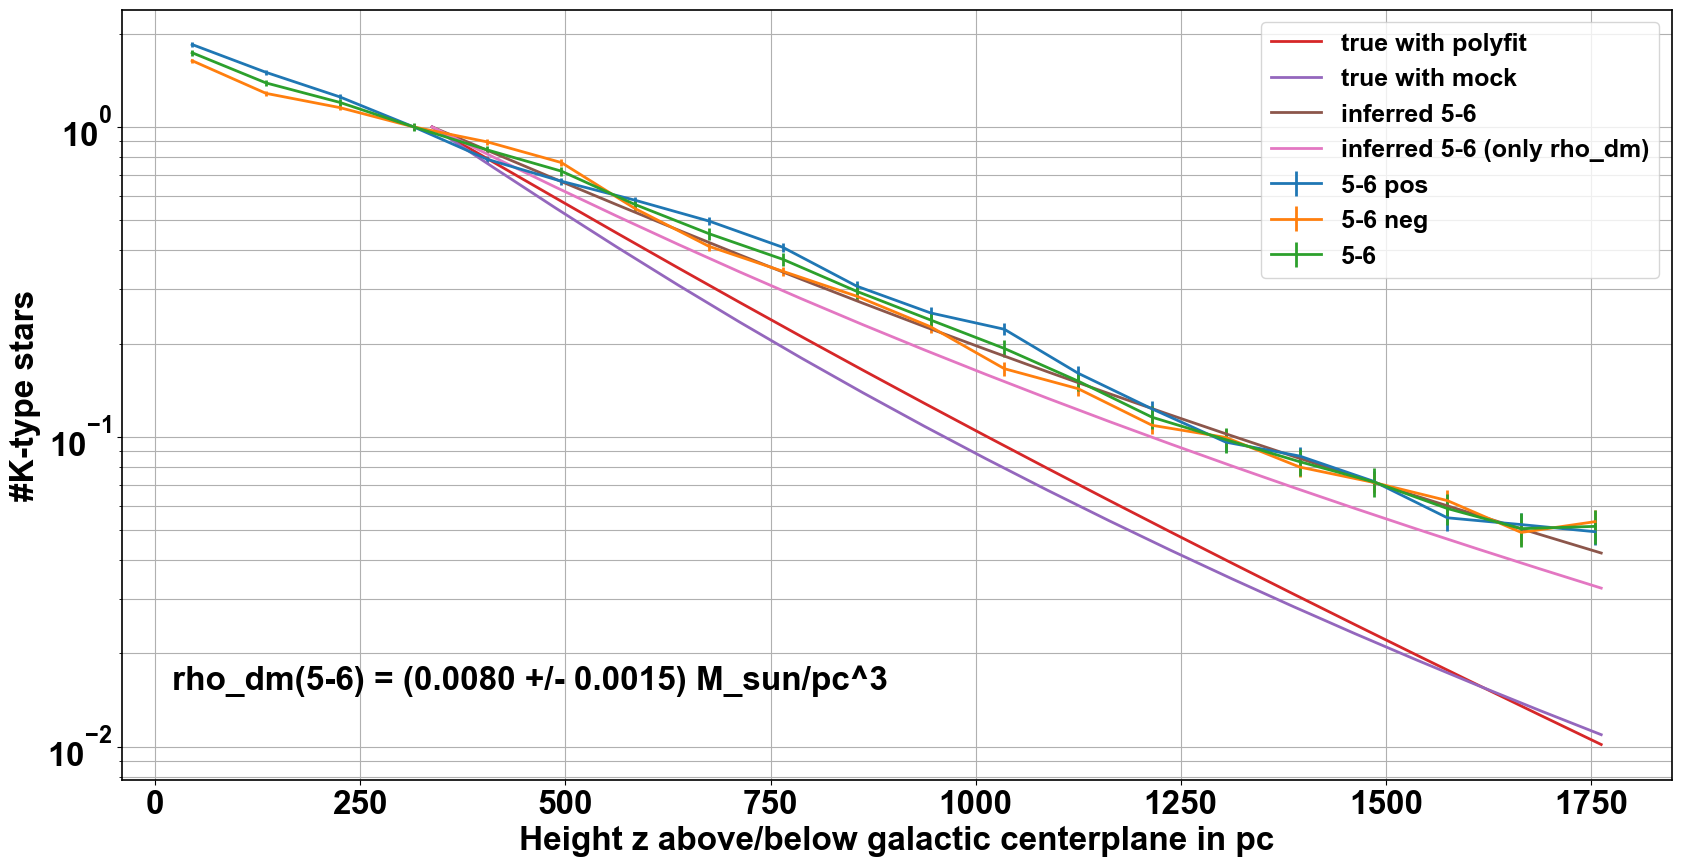

In [209]:
import util
from jax import numpy as jnp
from importlib import reload
reload(util)

rho_dm = 0.025
rhos = jnp.array([0.021, 0.016, 0.012, 0.0009, 0.0006, 0.0031, 0.0015, 0.0020, 0.0022, 0.007, 0.0135, 0.006, 0.002, 0.0035, 0.0001])
sigmas = jnp.array([4., 7., 9., 40., 20., 7.5, 10.5, 14., 18., 18.5, 18.5, 20., 20., 37., 100.])
erhos = jnp.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]) * rhos
esigmas = jnp.array([1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.])

z1 = 1800.
z2 = 300.
n = 1801
poly = np.loadtxt(f'real data/poly_58.txt')
n_bins = 20

uz, zs = util.diffraxDopri5(rho_dm, params, z1, n)

vdfo_norm_calc_poly, z_poly = util.vdfo_norm(z2, z1, zs, uz, n, poly)
integral_poly, z_borders_poly = util.binning(vdfo_norm_calc_poly, z_poly, z2, z1, n, n_bins)
n_true_poly = integral_poly /integral_poly[0]
z_true_poly = (z_borders_poly[1:] + z_borders_poly[:-1]) / 2

vdfo_norm_calc_mock, z_mock = util.vdfo_norm(z2, z1, zs, uz, n, poly, mock=True)
integral_mock, z_borders_mock = util.binning(vdfo_norm_calc_mock, z_mock, z2, z1, n, n_bins)
n_true_mock = integral_mock /integral_mock[0]
z_true_mock = (z_borders_mock[1:] + z_borders_mock[:-1]) / 2


rho_dm_56 = jnp.array(pd.read_csv('real data2/rho_56.csv', header=None).iloc[:,0])[-1]
erho_dm_56 = jnp.array(pd.read_csv('real data2/rho_56.csv', header=None).iloc[:,1])[-1]
rhos_56 = jnp.array(pd.read_csv('real data2/rho_56.csv', header=None).iloc[:,0])[-16:-1]
erhos_56 = jnp.array(pd.read_csv('real data2/rho_56.csv', header=None).iloc[:,1])[-16:-1]
sigmas_56 = jnp.array(pd.read_csv('real data2/sigma_56.csv', header=None).iloc[:,0])[-15:]
esigmas_56 = jnp.array(pd.read_csv('real data2/sigma_56.csv', header=None).iloc[:,1])[-15:]
params_56 = jnp.transpose(jnp.vstack((jnp.array(rhos_56), jnp.array(sigmas_56))))

# rho_dm_67 = jnp.array(pd.read_csv('real data/rho_67.csv', header=None).iloc[:,0])[-1]
# rhos_67 = jnp.array(pd.read_csv('real data/rho_67.csv', header=None).iloc[:,0])[-16:-1]
# sigmas_67 = jnp.array(pd.read_csv('real data/sigma_67.csv', header=None).iloc[:,0])[-15:]
# params_67 = jnp.transpose(jnp.vstack((jnp.array(rhos_67), jnp.array(sigmas_67))))
                          
# rho_dm_78 = jnp.array(pd.read_csv('real data/rho_78.csv', header=None).iloc[:,0])[-1]

uz_56, zs_56 = util.diffraxDopri5(rho_dm_56, params_56, z1, n)
vdfo_norm_calc_56, z_56 = util.vdfo_norm(z2, z1, zs_56, uz_56, n, poly)
integral_56, z_borders_56 = util.binning(vdfo_norm_calc_56, z_56, z2, z1, n, n_bins)
n_true_56 = integral_56 /integral_56[0]
z_true_56 = (z_borders_56[1:] + z_borders_56[:-1]) / 2

uz_56_2, zs_56_2 = util.diffraxDopri5(rho_dm_56, params, z1, n)
vdfo_norm_calc_56_2, z_56_2 = util.vdfo_norm(z2, z1, zs_56_2, uz_56_2, n, poly)
integral_56_2, z_borders_56_2 = util.binning(vdfo_norm_calc_56_2, z_56_2, z2, z1, n, n_bins)
n_true_56_2 = integral_56_2 /integral_56_2[0]
z_true_56_2 = (z_borders_56_2[1:] + z_borders_56_2[:-1]) / 2

# uz_67, zs_67 = util.diffraxDopri5(rho_dm_67, params, z1, n)
# vdfo_norm_calc_67, z_67 = util.vdfo_norm(z2, z1, zs_67, uz_67, n, poly)
# integral_67, z_borders_67 = util.binning(vdfo_norm_calc_67, z_67, z2, z1, n, n_bins)
# n_true_67 = integral_67 /integral_67[norm]
# z_true_67 = (z_borders_67[1:] + z_borders_67[:-1]) / 2

# uz_67_2, zs_67_2 = util.diffraxDopri5(rho_dm_67, params_67, z1, n)
# vdfo_norm_calc_67_2, z_67_2 = util.vdfo_norm(z2, z1, zs_67_2, uz_67_2, n, poly)
# integral_67_2, z_borders_67_2 = util.binning(vdfo_norm_calc_67_2, z_67_2, z2, z1, n, n_bins)
# n_true_67_2 = integral_67_2 /integral_67_2[norm]
# z_true_67_2 = (z_borders_67_2[1:] + z_borders_67_2[:-1]) / 2

# uz_78, zs_78 = util.diffraxDopri5(rho_dm_78, params, z1, n)
# vdfo_norm_calc_78, z_78 = util.vdfo_norm(z2, z1, zs_78, uz_78, n, poly)
# integral_78, z_borders_78 = util.binning(vdfo_norm_calc_78, z_78, z2, z1, n, n_bins)
# n_true_78 = integral_78 /integral_78[norm]
# z_true_78 = (z_borders_78[1:] + z_borders_78[:-1]) / 2



n_56 = np.loadtxt('real data/n_56.txt')
# n_67 = np.loadtxt('real data/n_67.txt')
# n_78 = np.loadtxt('real data/n_78.txt')
# n_58 = np.loadtxt('real data/n_58.txt')

bins_56 = np.loadtxt('real data/bins_56.txt')
# bins_67 = np.loadtxt('real data/bins_67.txt')
# bins_78 = np.loadtxt('real data/bins_78.txt')
# bins_58 = np.loadtxt('real data/bins_58.txt')

z_56 = (bins_56[1:]+bins_56[:-1])/2
# z_67 = (bins_67[1:]+bins_67[:-1])/2
# z_78 = (bins_78[1:]+bins_78[:-1])/2
# z_58 = (bins_58[1:]+bins_58[:-1])/2

pos = np.where(z_56 >= 0)
neg = np.where(z_56 < 0)
norm = np.where(bins_56<=z2)[0][-1]-len(bins_56)//2

fig = plt.figure(figsize=(20,10))
plt.yscale("log")
# plt.xlim(0., 1800)
# plt.ylim(1e-2, 3)
plt.xlabel("Height z above/below galactic centerplane in pc")
plt.ylabel("#K-type stars")

plt.errorbar(z_56[pos], n_56[pos]/n_56[pos][norm], yerr=np.sqrt(n_56)[pos]/n_56[pos][norm], label="5-6 pos")
plt.errorbar(abs(z_56[neg]), n_56[neg]/n_56[neg][-1-norm], yerr=np.sqrt(n_56)[neg]/n_56[neg][-1-norm], label="5-6 neg")
plt.errorbar(z_56[pos], (n_56[pos]+np.flip(n_56[neg]))/(n_56[pos]+np.flip(n_56[neg]))[norm], yerr=np.sqrt((n_56[pos]+np.flip(n_56[neg])))/(n_56[pos]+n_56[neg])[norm], label="5-6")
# plt.errorbar(z_67[pos], n_67[pos]/n_67[pos][norm], yerr=np.sqrt(n_67)[pos]/n_67[pos][2], label="6-7 pos")
# plt.errorbar(abs(z_67[neg]), n_67[neg]/n_67[neg][-1-norm], yerr=np.sqrt(n_67)[neg]/n_67[neg][-3], label="6-7 neg")
# plt.errorbar(z_67[pos], (n_67[pos]+np.flip(n_67[neg]))/(n_67[pos]+np.flip(n_67[neg]))[norm], yerr=np.sqrt((n_67[pos]+np.flip(n_67[neg])))/(n_67[pos]+n_67[neg])[2], label="6-7")
# plt.errorbar(z_78[pos], n_78[pos]/n_78[pos][norm], yerr=np.sqrt(n_78)[pos]/n_78[pos][2], label="7-8 pos")
# plt.errorbar(abs(z_78[neg]), n_78[neg]/n_78[neg][-1-norm], yerr=np.sqrt(n_78)[neg]/n_78[neg][-3], label="7-8 neg")
# plt.errorbar(z_58[pos], n_58[pos]/n_58[pos][norm], yerr=np.sqrt(n_58)[pos]/n_58[pos][2], label="5-8 pos")
# plt.errorbar(abs(z_58[neg]), n_58[neg]/n_58[neg][-1-norm], yerr=np.sqrt(n_58)[neg]/n_58[neg][-3], label="5-8 neg")

plt.plot(z_true_poly, n_true_poly, label="true with polyfit")
plt.plot(z_true_mock, n_true_mock, label="true with mock")
plt.plot(z_true_56, n_true_56, label="inferred 5-6")
plt.plot(z_true_56_2, n_true_56_2, label="inferred 5-6 (only rho_dm)")
# plt.errorbar(z_true_67, n_true_67, label="true 67")
# plt.errorbar(z_true_67_2, n_true_67_2, label="true 67_2")
# plt.errorbar(z_true_78, n_true_78, label="true 78")

plt.figtext(0.15, 0.2, f'rho_dm(5-6) = ({rho_dm_56:.4f} +/- {erho_dm_56:.4f}) M_sun/pc^3')
plt.grid(which='both')
plt.legend(fontsize='18')

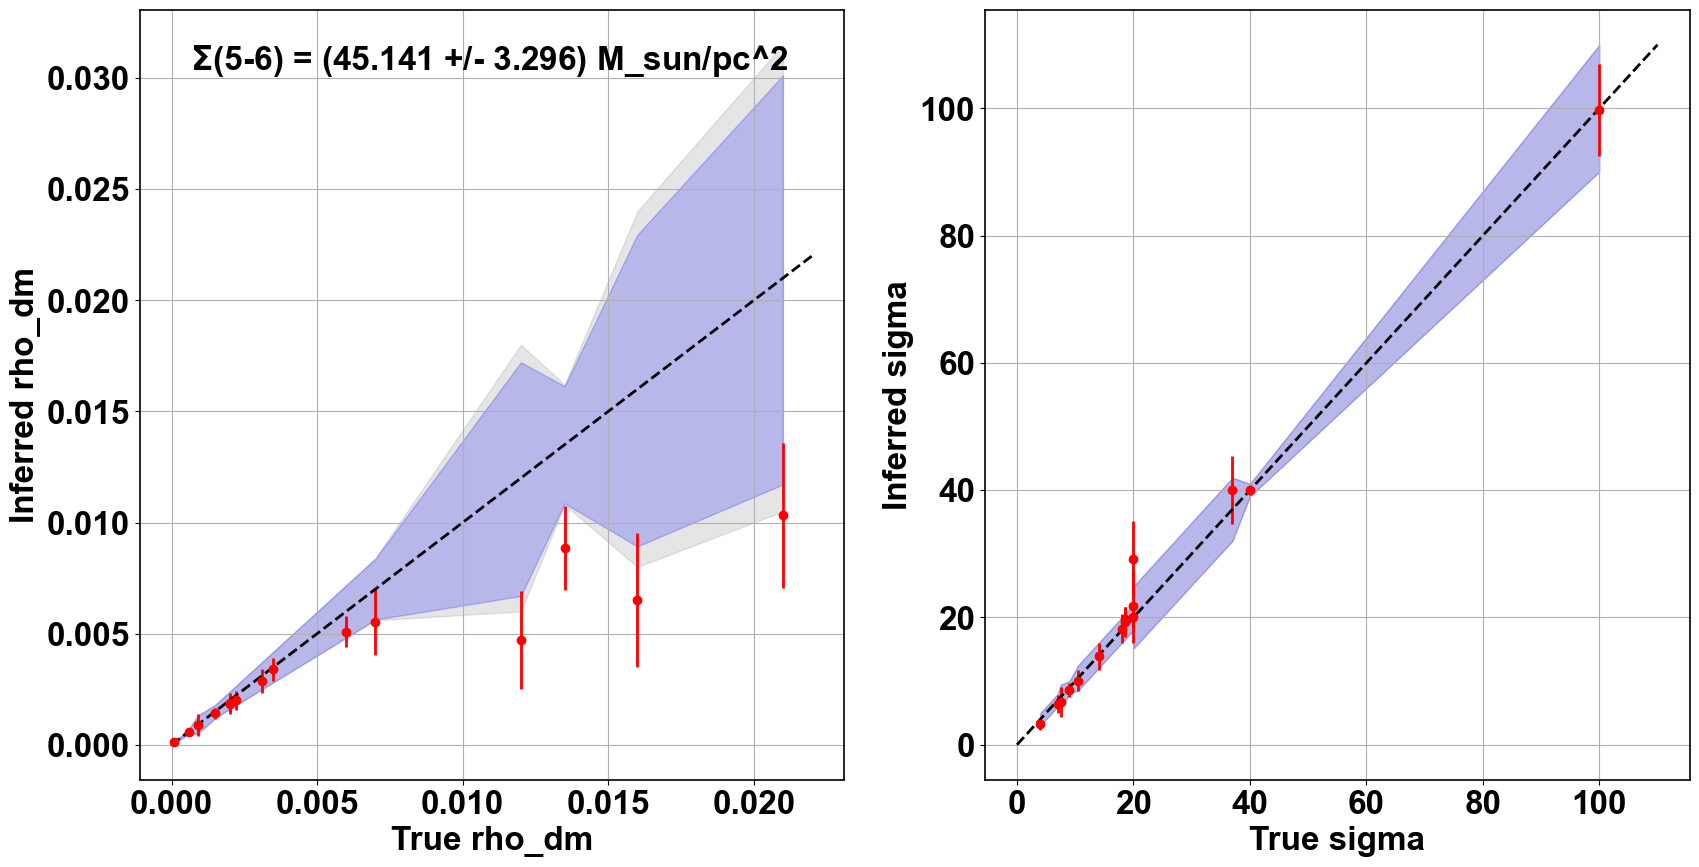

In [223]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

def bounds(mean, std):
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    mu_ = jnp.exp(mu)
    sigma_ = jnp.exp(sigma)
    return mu_/sigma_, mu_*sigma_

ax[0].errorbar(rhos, rhos_56, yerr=erhos_56, fmt='o', color='red')
ax[0].plot([0, 0.022], [0, 0.022], color='black', linestyle='--')
rho_sorted = np.argsort(rhos)
ax[0].fill_between(rhos[rho_sorted], (rhos+erhos)[rho_sorted], y2=(rhos-erhos)[rho_sorted], alpha=0.2, color='gray', label='gauß 0.683')
ax[0].fill_between(rhos[rho_sorted], bounds(rhos[rho_sorted], erhos[rho_sorted])[0], y2=bounds(rhos[rho_sorted], erhos[rho_sorted])[1], alpha=0.2, color='blue', label='lognormal 0.683')
ax[0].set_xlabel("True rho_dm")
ax[0].set_ylabel("Inferred rho_dm")
ax[0].grid()

ax[1].errorbar(sigmas, sigmas_56, yerr=esigmas_56, fmt='o', color='red')
ax[1].plot([0, 110], [0, 110], color='black', linestyle='--')
sigma_sorted = np.argsort(sigmas)
ax[1].fill_between(sigmas[sigma_sorted], (sigmas+esigmas)[sigma_sorted], y2=(sigmas-esigmas)[sigma_sorted], alpha=0.2, color='gray', label='gauß 0.683')
ax[1].fill_between(sigmas[sigma_sorted], bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[0], y2=bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[1], alpha=0.2, color='blue', label='lognormal 0.683')
ax[1].set_xlabel("True sigma")
ax[1].set_ylabel("Inferred sigma")
ax[1].grid()

sd_56 = jnp.array(pd.read_csv('real data2/sd_56.csv', header=None).iloc[:,0])[-1]
esd_56 = jnp.array(pd.read_csv('real data2/sd_56.csv', header=None).iloc[:,1])[-1]
plt.figtext(0.15, 0.82, f'$\Sigma$(5-6) = ({sd_56:.3f} +/- {esd_56:.3f}) M_sun/pc^2')
plt.show()

# fig = plt.figure(figsize=(20,10))
# plt.errorbar(params[:,1], params_67[:,1], yerr = np.array([   1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.]), fmt='o')
# plt.plot([0,100], [0,100], color='black', linestyle='--')

# fig = plt.figure(figsize=(20,10))
# plt.errorbar(params[:,0], params_67[:,0], yerr = np.array([ 0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2])*params[:,0], fmt='o')
# plt.plot([0,0.02], [0,0.02], color='black', linestyle='--')

In [185]:
# absz_56 = z_56[int(len(z_56)/2):]
# absz_67 = z_67[int(len(z_67)/2):]
# absz_78 = z_78[int(len(z_78)/2):]
# absz_58 = z_58[int(len(z_58)/2):]

# n2_56 = n_56[int(len(n_56)/2):] + n_56[int(len(n_56)/2)-1::-1]
# n2_67 = n_67[int(len(n_67)/2):] + n_67[int(len(n_67)/2)-1::-1]
# n2_78 = n_78[int(len(n_78)/2):] + n_78[int(len(n_78)/2)-1::-1]
# n2_58 = n_58[int(len(n_58)/2):] + n_58[int(len(n_58)/2)-1::-1]

# fig = plt.figure(figsize=(20,10))
# plt.xlabel("Height |z| above/below us in pc")
# plt.ylabel("#K-type stars")
# plt.errorbar(absz_56, n2_56/np.sum(n2_56[2:16]), yerr=np.sqrt(n2_56)/np.sum(n2_56[2:16]), label="5-6")
# plt.errorbar(absz_67, n2_67/np.sum(n2_67[2:16]), yerr=np.sqrt(n2_67)/np.sum(n2_67[2:16]), label="6-7")
# plt.errorbar(absz_78, n2_78/np.sum(n2_78[2:16]), yerr=np.sqrt(n2_78)/np.sum(n2_78[2:16]), label="7-8")
# plt.errorbar(absz_58, n2_58/np.sum(n2_58[2:16]), yerr=np.sqrt(n2_58)/np.sum(n2_58[2:16]), label="5-8")
#  #normiert auf fläche zwischen 200, 1600
# plt.axvline(650, color="gray", ls="--")
# plt.axvline(1000, color="gray", ls="--")
# plt.axvline(1600, color="gray", ls="--")
# plt.axvline(100, color="gray", ls="--")
# plt.axvline(250, color="gray", ls="--")
# plt.grid()
# plt.legend()